In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from tqdm import tqdm

In [3]:
import mpmath as mp
mp.mp.dps = 50

In [4]:
def probit_moment(k, N, r):        # r = 1 or 2
    beta_norm = mp.beta(k, N+1-k)
    SQRT2   = mp.sqrt(2)
    SQRT2PI = mp.sqrt(2*mp.pi)
    
    # Standard–normal PDF   φ(z)  = (2π)^{-½} · e^{ -z² / 2 }
    phi  = lambda z: mp.e**(-z*z/2) / SQRT2PI
    
    # Standard–normal CDF   Φ(z)  = ½ · [ 1 + erf( z / √2 ) ]
    Phi  = lambda z: 0.5 * (1 + mp.erf(z / SQRT2))
    # phi   = norm.pdf
    # Phi   = norm.cdf
    integrand = lambda z: (z**r *
                           Phi(z)**(k-1) *
                           (1-Phi(z))**(N-k) *
                           phi(z))
    return float(mp.quad(integrand, [-mp.inf, mp.inf]) / beta_norm)

def cN_gaussian(N, m1s=None):
    if m1s is None:
        m1s = np.array([probit_moment(k+1, N, 1) for k in range(N)])
    return np.mean(m1s**2)

def expected_wasserstein_loss_gaussian(mu1, sigma1, mu2, sigma2, N, m1s=None):
    k   = np.arange(1.0, N + 1.0)
    if m1s is None:
        m1s = np.array([probit_moment(k[i], N, 1) for i in range(N)])
    return (mu1 - mu2)**2 + sigma1**2 + sigma2**2 - 2*cN_gaussian(N, m1s=m1s)*sigma1*sigma2

def true_wass_loss_gaussian(mu1, sigma1, mu2, sigma2):
    return (mu1 - mu2)**2 + (sigma1 - sigma2)**2

def analytic_sol_gaussian(mu1, sigma1, N, m1s = None):
    # argmin of E_{\mu,\nu}[W(\hat{\mu}_N, \hat{\nu}_N)]
    return mu1, sigma1 * cN_gaussian(N, m1s=m1s)

def cN_exponential(N):
    k   = np.arange(1.0, N + 1.0)
    return float(0.5*np.mean([(mp.digamma(N+1-k[i]) - mp.digamma(N+1))**2 for i in range(N)]))

def expected_wasserstein_loss_exponential(a1, a2, N, cN = None):
    th1 = np.sqrt(2)/a1
    th2 = np.sqrt(2)/a2
    if cN is None:
        cN = cN_exponential(N)
    return th1**2 + th2**2 - 2*cN*th1*th2

def analytic_sol_exponential(a1, N, cN = None):
    th1 = np.sqrt(2)/a1
    if cN is None:
        cN = cN_exponential(N)
    th_hat = cN*th1
    return np.sqrt(2)/th_hat

def true_wass_loss_exponential(a1, a2):
    return 2*(1/a1 - 1/a2)**2

In [5]:
Nset = [2,3,5,10,15,20,35,50,75,100]
cN_vals_gaussian = np.empty(len(Nset))
cN_vals_exponential = np.empty(len(Nset))
for i, N in enumerate(Nset):
    print(N)
    cN_vals_gaussian[i] = cN_gaussian(N)
    cN_vals_exponential[i] = cN_exponential(N)

2
3
5
10
15
20
35
50
75
100


In [6]:
Nset0 = [2,3,5,10,15,20,35,50,75,100]

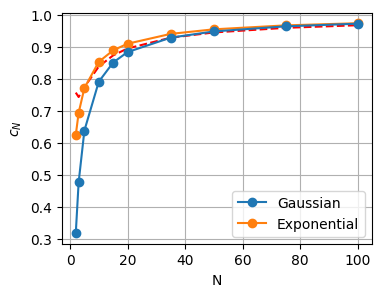

In [7]:
plt.figure(figsize=(4,3))
plt.plot(Nset0, cN_vals_gaussian, label='Gaussian', marker='o', zorder=10)
plt.plot(Nset0, cN_vals_exponential, label='Exponential', marker='o', zorder=5)
plt.plot(Nset0, 1 - 0.7*np.log(np.array(Nset0))/np.array(Nset0), 'r--')
plt.grid()
plt.xlabel('N')
plt.ylabel(r'$c_N$')
plt.legend()
# plt.savefig(f'./fig_cN_location_scale.pdf', format='pdf', bbox_inches="tight", dpi=300)

Text(0, 0.5, '$c_N$')

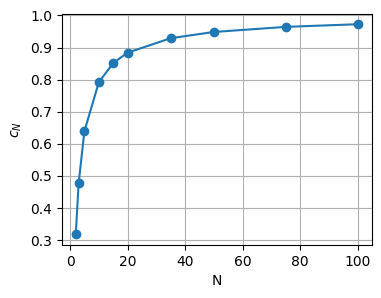

In [8]:
Nset = [2,3,5,10,15,20,35,50,75,100]
plt.figure(figsize=(4,3))
plt.plot(Nset, cN_vals_gaussian, marker='o', zorder=10)
# plt.plot(Nset, cN_vals_exponential, label='Exponential', marker='o', zorder=5)
plt.grid()
plt.xlabel('N')
plt.ylabel(r'$c_N$')
# plt.legend()
# plt.savefig(f'./fig_cN_location_scale_gaussian.pdf', format='pdf', bbox_inches="tight", dpi=300)

In [9]:
mu1, mu2, sigma1 = 0, 0, 1
sigma2s = np.linspace(0.1, 2, 101)

In [10]:
m1s_set = {}
Nset = [2, 5, 10, 20, 50, 100]
for N in Nset:
    m1s_set[str(N)] = np.array([probit_moment(i+1, N, 1) for i in range(N)])

In [11]:
true_loss_gaussian_set = np.array([true_wass_loss_gaussian(mu1, sigma1, mu2, sigma2) for sigma2 in sigma2s])
expected_loss_gaussian_set = {}
expected_loss_gaussian_minimizer_set = {}
for N in Nset:
    expected_loss_gaussian_set[str(N)] = np.array([expected_wasserstein_loss_gaussian(mu1, sigma1, mu2, sigma2, N, m1s=m1s_set[str(N)]) for sigma2 in sigma2s])
    mu_hat, sigma_hat = analytic_sol_gaussian(mu1, sigma1, N, m1s = m1s_set[str(N)])
    expected_loss_gaussian_minimizer_set[str(N)] = sigma_hat

In [12]:
# empirical_loss_gaussian_set = {}
# Ntrial = 10000
# for N in Nset:
#     temp_loss = np.empty((len(sigma2s), Ntrial))
#     for j, sigma2 in enumerate(sigma2s):
#         for t in range(Ntrial):
#             x1 = np.sort(np.random.randn(N) * sigma1 + mu1)
#             x2 = np.sort(np.random.randn(N) * sigma2 + mu2)
#             temp_loss[j,t] = np.mean((x1-x2)**2)
#     empirical_loss_gaussian_set[str(N)] = temp_loss

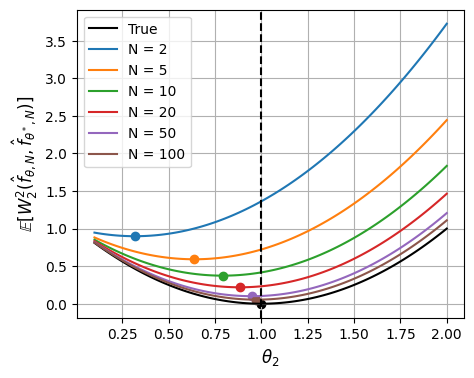

In [13]:
plt.figure(figsize=(5,4))
plt.plot(sigma2s, true_loss_gaussian_set, 'k', label='True')
plt.scatter(sigma1, 0, marker='o', c='k')
for i, N in enumerate(Nset):
    plt.plot(sigma2s, expected_loss_gaussian_set[str(N)], label=f'N = {N}')
    # plt.plot(sigma2s, np.mean(empirical_loss_gaussian_set[str(N)], axis=1), '--', c=plt.gca().lines[-1].get_color())
    temp_sigma = expected_loss_gaussian_minimizer_set[str(N)]
    plt.scatter(temp_sigma, expected_wasserstein_loss_gaussian(mu1, sigma1, mu2, temp_sigma, N, m1s=m1s_set[str(N)]), marker='o')
plt.axvline([sigma1], color="k", linestyle="dashed")
plt.grid()
plt.xlabel(r'$\theta_2$', fontsize=12)
plt.ylabel(r'$\mathbb{E}[W_2^2(\hat{f}_{\theta, N}, \hat{f}_{\theta^*, N})]$', fontsize=12)
plt.legend()
# plt.savefig(f'./fig_expected_loss_gaussian.pdf', format='pdf', bbox_inches="tight", dpi=300)

In [14]:
sigma1s = np.linspace(0.1, 2., 201)

expected_was_diagonal = np.empty((len(Nset), len(sigma1s)))
for i, N in enumerate(Nset):
    for j, sigma1 in enumerate(sigma1s):
        expected_was_diagonal[i,j] = expected_wasserstein_loss_gaussian(mu1, sigma1, mu2, sigma1, N, m1s=m1s_set[str(N)])

Text(0, 0.5, '$\\mathbb{E}[W_2^2(\\hat{f}_{\\theta,N}, \\hat{f}_{\\theta,N})]$')

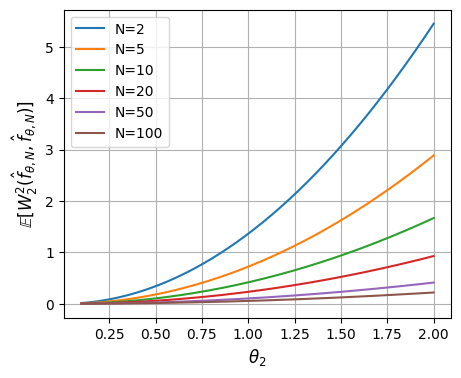

In [15]:
plt.figure(figsize=(5,4))
for i, N in enumerate(Nset):
    plt.plot(sigma1s, expected_was_diagonal[i], label=f'N={N}')
plt.grid()
plt.legend()
plt.xlabel(r'$\theta_2$', fontsize=12)
plt.ylabel(r'$\mathbb{E}[W_2^2(\hat{f}_{\theta,N}, \hat{f}_{\theta,N})]$', fontsize=12)
# plt.savefig(f'./fig_expected_loss_diagonal.pdf', format='pdf', bbox_inches="tight", dpi=300)

### debias

In [16]:
Nset

[2, 5, 10, 20, 50, 100]

In [17]:
sigma1s_ = np.linspace(0.1, 2., 101)

expected_was_diagonal_ = np.empty((len(Nset), len(sigma1s_)))
for i, N in enumerate(Nset):
    for j, sigma1 in enumerate(sigma1s_):
        expected_was_diagonal_[i,j] = expected_wasserstein_loss_gaussian(mu1, sigma1, mu2, sigma1, N, m1s=m1s_set[str(N)])

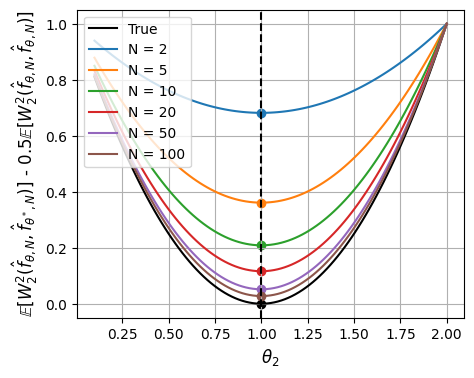

In [19]:
sigma1 = 1
plt.figure(figsize=(5,4))
plt.plot(sigma2s, true_loss_gaussian_set, 'k', label='True')
plt.scatter(sigma1, 0, marker='o', c='k')
for i, N in enumerate(Nset):
    plt.plot(sigma2s, expected_loss_gaussian_set[str(N)] - 0.5*expected_was_diagonal_[i], label=f'N = {N}')
    # plt.plot(sigma2s, np.mean(empirical_loss_gaussian_set[str(N)], axis=1), '--', c=plt.gca().lines[-1].get_color())
    temp_sigma = sigma1
    plt.scatter(temp_sigma, expected_wasserstein_loss_gaussian(mu1, sigma1, mu2, temp_sigma, N, m1s=m1s_set[str(N)]) \
                - 0.5*expected_wasserstein_loss_gaussian(mu1, temp_sigma, mu2, temp_sigma, N, m1s=m1s_set[str(N)]), marker='o')
plt.axvline([sigma1], color="k", linestyle="dashed")
plt.grid()
plt.xlabel(r'$\theta_2$', fontsize=12)
plt.ylabel(r'$\mathbb{E}[W_2^2(\hat{f}_{\theta, N}, \hat{f}_{\theta^*, N})]$ - 0.5$\mathbb{E}[W_2^2(\hat{f}_{\theta, N}, \hat{f}_{\theta, N})]$', fontsize=12)
plt.legend(loc='upper left')
# plt.savefig(f'./fig_expected_loss_gaussian_debias.pdf', format='pdf', bbox_inches="tight", dpi=300)

In [1]:
a=1

In [44]:
N = 10
sigma1s_ = np.linspace(0.1, 2., 101)
sigma2s_ = np.linspace(0.1, 2., 101)
expected_was = np.empty((len(sigma2s_), len(sigma1s_)))
for i, sigma1 in enumerate(sigma1s_):
    for j, sigma2 in enumerate(sigma2s_):
        expected_was[j,i] = expected_wasserstein_loss_gaussian(mu1, sigma1, mu2, sigma2, N, m1s=m1s_set[str(N)])

In [45]:
expected_was_diag = np.empty((len(sigma2s_), len(sigma1s_)))
for i, sigma1 in enumerate(sigma1s_):
    for j, sigma2 in enumerate(sigma2s_):
        expected_was_diag[j,i] = expected_wasserstein_loss_gaussian(mu1, sigma2, mu2, sigma2, N, m1s=m1s_set[str(N)])

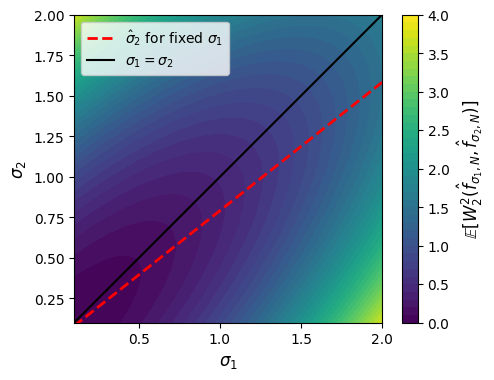

In [38]:
plt.figure(figsize=(5,4))
clev = np.linspace(0,4.0,41) 
h = plt.contourf(sigma1s_, sigma2s_, expected_was, clev)
cbar = plt.colorbar()
cbar.set_label(r'$\mathbb{E}[W_2^2(\hat{f}_{\sigma_1,N}, \hat{f}_{\sigma_2,N})]$', fontsize=12)
#plt.plot(w_list_np[:,0], w_list_np[:,1], c='orange', marker='o')

plt.axis('scaled')
plt.xlabel(r'$\sigma_1$', fontsize=12)
plt.ylabel(r'$\sigma_2$', fontsize=12)
plt.xlim([sigma1s_.min(), sigma1s_.max()])
plt.ylim([sigma2s_.min(), sigma2s_.max()])
plt.plot(sigma1s_, sigma1s_*cN_gaussian(N, m1s=m1s_set[str(N)]), 'r--', linewidth=2, label=r'$\hat{\sigma}_2$ for fixed $\sigma_1$')
plt.plot(sigma1s_, sigma2s_, 'k', label=r'$\sigma_1 = \sigma_2$')
plt.legend()
# plt.savefig(f'./fig_expected_loss_poisson_rate.pdf', format='pdf', bbox_inches="tight", dpi=300)
plt.show()


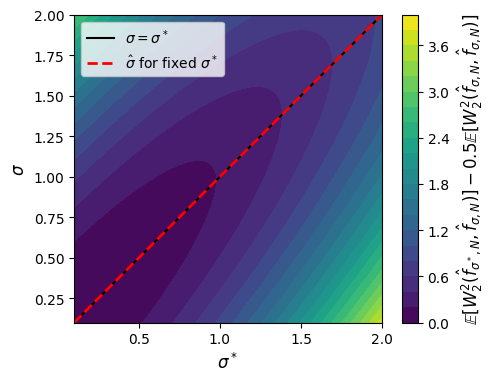

In [54]:
plt.figure(figsize=(5,4))
clev = np.linspace(0,4.0,21) 
h = plt.contourf(sigma1s_, sigma2s_, expected_was - 0.5*expected_was_diag, clev)
cbar = plt.colorbar()
cbar.set_label(r'$\mathbb{E}[W_2^2(\hat{f}_{\sigma^*,N}, \hat{f}_{\sigma,N})] - 0.5\mathbb{E}[W_2^2(\hat{f}_{\sigma,N}, \hat{f}_{\sigma,N})]$', fontsize=12)
#plt.plot(w_list_np[:,0], w_list_np[:,1], c='orange', marker='o')

plt.axis('scaled')
plt.xlabel(r'$\sigma^*$', fontsize=12)
plt.ylabel(r'$\sigma$', fontsize=12)
plt.xlim([sigma1s_.min(), sigma1s_.max()])
plt.ylim([sigma2s_.min(), sigma2s_.max()])
plt.plot(sigma1s_, sigma2s_, 'k', label=r'$\sigma = \sigma^*$')
plt.plot(sigma1s_, sigma1s_, 'r--', linewidth=2, label=r'$\hat{\sigma}$ for fixed $\sigma^*$')
plt.legend()
plt.savefig(f'./fig_expected_loss_location_scale_modified.pdf', format='pdf', bbox_inches="tight", dpi=300)
plt.show()


In [14]:
th1 = 1
th2s = np.linspace(0.1, 2, 101)
a1 = np.sqrt(2)/th1
a2s = np.sqrt(2)/th2s

In [15]:
cN_set = {}
Nset = [2, 5, 10, 20, 50, 100]
for N in Nset:
    cN_set[str(N)] = cN_exponential(N)

In [16]:
true_loss_exponential_set = np.array([true_wass_loss_exponential(a1, a2) for a2 in a2s])
expected_loss_exponential_set = {}
expected_loss_exponential_minimizer_set = {}
for N in Nset:
    expected_loss_exponential_set[str(N)] = np.array([expected_wasserstein_loss_exponential(a1, a2, N, cN = cN_set[str(N)]) for a2 in a2s])
    a_hat = analytic_sol_exponential(a1, N)
    expected_loss_exponential_minimizer_set[str(N)] = a_hat

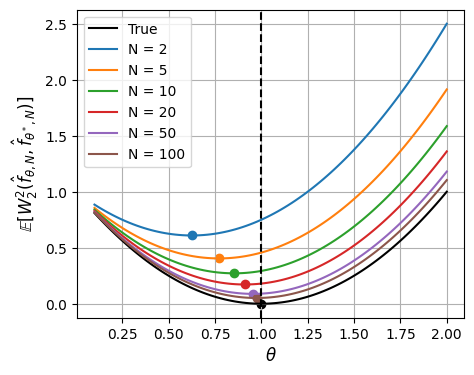

In [17]:
plt.figure(figsize=(5,4))
plt.plot(th2s, true_loss_exponential_set, 'k', label='True')
plt.scatter(th1, 0, marker='o', c='k')
for i, N in enumerate(Nset):
    plt.plot(th2s, expected_loss_exponential_set[str(N)], label=f'N = {N}')
    temp_a = expected_loss_exponential_minimizer_set[str(N)]
    plt.scatter(np.sqrt(2)/temp_a, expected_wasserstein_loss_exponential(a1, temp_a, N, cN = cN_set[str(N)]), marker='o')
plt.axvline([th1], color="k", linestyle="dashed")
plt.grid()
plt.xlabel(r'$\theta$', fontsize=12)
plt.ylabel(r'$\mathbb{E}[W_2^2(\hat{f}_{\theta, N}, \hat{f}_{\theta^*, N})]$', fontsize=12)
plt.legend()
# plt.savefig(f'./fig_expected_loss_exponential.pdf', format='pdf', bbox_inches="tight", dpi=300)

In [18]:
Nset = [2, 5, 10, 20, 50, 100]
th1s = np.linspace(0.1, 2., 201)
a1s = np.sqrt(2)/th1s
expected_was_diagonal_exponential = np.empty((len(Nset), len(a1s)))
for i, N in enumerate(Nset):
    for j, a1 in enumerate(a1s):
        expected_was_diagonal_exponential[i,j] = expected_wasserstein_loss_exponential(a1, a1, N)

Text(0, 0.5, '$\\mathbb{E}[W_2^2(\\hat{f}_{\\theta,N}, \\hat{f}_{\\theta,N})]$')

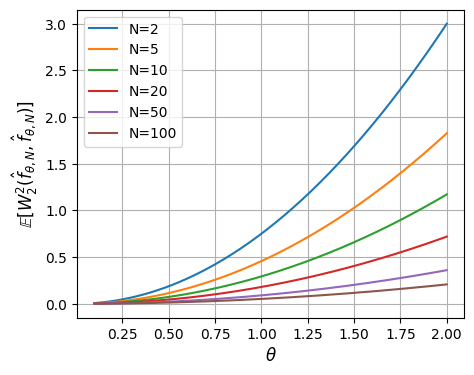

In [19]:
plt.figure(figsize=(5,4))
for i, N in enumerate(Nset):
    plt.plot(th1s, expected_was_diagonal_exponential[i], label=f'N={N}')
plt.grid()
plt.legend()
plt.xlabel(r'$\theta$', fontsize=12)
plt.ylabel(r'$\mathbb{E}[W_2^2(\hat{f}_{\theta,N}, \hat{f}_{\theta,N})]$', fontsize=12)
# plt.savefig(f'./fig_expected_loss_exponential_diagonal.pdf', format='pdf', bbox_inches="tight", dpi=300)